# 1. Mô tả

- File này để trả lời 2 câu hỏi có thể trả lời được dựa vào dữ liệu sẵn có. Ngoài ra, để tăng thách thức (aka công việc), các câu hỏi này để trả lời thiếu phục, ý nghĩa và phù hợp với thực tế còn cần nhóm phải tra cứu, tìm tòi, tích hợp thêm một số thông tin bên ngoài. 

- Các câu hỏi chỉ dựa vào mỗi dữ liệu `drop_dup_data.csv` (dữ liệu nguyên bản, chỉ loại bỏ dòng trùng lặp) để trả lời, rút ra insight và giả thuyết đã được nhóm trình bày ở **02_general_eda.ipynb**. 

- Nghĩa là nhóm đã có và trình bày nhiều hơn 4 câu hỏi / giả thuyết, và 4 câu hỏi được trình bày ở 2 file 03.ipynb là những câu hỏi khó, thử thách nhất.

# 2. Câu hỏi

## Câu hỏi 1: Lương ngành Data tăng là do giá trị thật hay do lạm phát?

**Cụ thể:**   
Phân tích mức tăng trưởng lương trung vị (median salary) hàng năm của các **Senior** trong ngành Data tại **thị trường Mỹ** (nơi chiếm đa số dữ liệu và sử dụng USD) và so sánh tốc độ tăng trưởng này với tỷ lệ lạm phát (CPI) của Mỹ trong cùng kỳ **2022-2025**.

### Động lực & Lợi ích

**Động lực:**  
Trong vài năm qua, con số lương ngành IT và Data được báo cáo là tăng phi mã. Tuy nhiên, nếu mức tăng này chỉ ngang bằng với lạm phát, thì sức mua thực tế của nhân sự không đổi. Việc xác định xem đây là tăng trưởng "thực" hay chỉ là "trượt giá" là rất quan trọng để đánh giá sức hấp dẫn thực sự của ngành.

**Lợi ích:**
- Giúp phân biệt giữa "bong bóng" lương và sự gia tăng giá trị nội tại của nghề.
- Xác định xem thị trường đang trong giai đoạn "bùng nổ" (Boom), "bão hòa" (Stagnation) hay "suy thoái" (Recession).

**Đối tượng quan tâm?**
- Người tìm việc: Để đặt kỳ vọng lương hợp lý và deal lương theo giá trị thực chứ không chỉ theo con số danh nghĩa.
- Nhà tuyển dụng: Để hoạch định ngân sách nhân sự, biết khi nào cần tăng lương để giữ chân nhân tài trước áp lực lạm phát.
- Người định hướng nghề nghiệp: Đánh giá tiềm năng dài hạn của ngành.

**Vấn đề thực tế:**  
Quyết định có nên chuyển việc để tăng lương hay không, và định vị mức lương đề xuất sao cho không bị lỗ thực tế.

## Câu hỏi 2: Cơn sốt AI (ChatGPT bùng nổ cuối 2022) tác động thế nào đến cấu trúc lương ngành Data?

**Cụ thể:**  
Phân loại cột `job_title` thành hai nhóm định danh **AI/ML** vs. **Traditional Data Roles**, sau đó tính toán mức lương trung bình (salary_in_usd) theo từng năm (work_year) và so sánh hệ số góc (độ dốc) của đường xu hướng để xem xu hướng lương giữa 2 nhóm như thể nào **sau năm 2022**.

### Động lực & Lợi ích

**Động lực:**  
Năm 2022, ChatGPT bùng nổ, thị trường công nghệ đang trải qua "cơn sốt" AI. Nhiều giả định cho rằng "kỹ sư AI/ML được tăng lương đột biến, còn Data Analyst truyền thống thì chững lại", nhưng thường chỉ dựa trên các nhận định cảm tính hoặc tin tức truyền thông. Việc phân tich dữ liệu thực tế sẽ giúp kiểm chứng nhận định trên.

**Lợi ích:**  
- Định lượng giá trị kỹ năng: Cho thấy mức trả thêm mà thị trường sẵn sàng trả cho các kỹ năng GenAI/ML so với kỹ năng phân tích dữ liệu thông thường.
- Dự báo xu hướng: Độ dốc của biểu đồ sẽ cho biết tốc độ tăng trưởng, giúp dự đoán liệu khoảng cách thu nhập giữa hai nhóm này sẽ nới rộng hay thu hẹp trong tương lai gần.

**Đối tượng quan tâm:**   
- Người lao động (Data Professionals): Các Data Analyst/Scientist đang cân nhắc xem có nên đầu tư thời gian học thêm về Deep Learning/LLMs để chuyển hướng sự nghiệp (pivot) hay không.
- Nhà tuyển dụng & HR: Cần dữ liệu chuẩn (benchmark) để xây dựng khung lương cạnh tranh cho các vị trí AI, tránh việc trả quá cao (overpaying) do hype hoặc quá thấp khiến mất nhân tài.
- Sinh viên & Cơ sở đào tạo: Định hướng chuyên ngành học phù hợp với nhu cầu và đãi ngộ của thị trường.

**Vấn đề thực tế:**  
- Quyết định lộ trình thăng tiến cá nhân: "Tôi nên đào sâu vào SQL/Tableau hay bắt đầu học PyTorch/TensorFlow để tối ưu thu nhập?"

# 3. Code tìm câu trả lời

### Import thư viện

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

In [2]:
# Load the dataset
df = pd.read_csv('../data/drop_dup_data.csv')

## Câu hỏi 1

### A. Tiền xử lí

**1. Lọc chỉ lấy thị trường Mỹ:**  
Để trả lời câu hỏi này một cách chính xác, chúng ta cần loại bỏ yếu tố sai lệch do sự thay đổi về địa lý. Ví dụ: 
- Dữ liệu các năm sau có thêm nhiều công ty Mỹ hơn nên lương trung bình năm đó cao hơn.
- Lạm phát ở Mỹ khác với lạm phát ở Việt Nam hay Ấn Độ.  
Do đó, để đảm bảo tính nhất quán, phân tích dưới đây chỉ xét riêng 1 thị trường. Ở đây chúng em chọn Mỹ (US) vì dữ liệu lương `salary_in_usd` thường lấy Mỹ làm chuẩn, điều này cũng giúp loại bỏ sai số do quy đổi tỷ giá tiền tệ giữa các nước, và dữ liệu lạm phát (CPI) của Mỹ rất minh bạch .

**2. Lọc chỉ lấy nhân viên Full-time:**  
Dataset này cung cấp Lương Tổng Cả Năm (Annual Salary), chứ không cung cấp Lương theo giờ (Hourly Rate) hay số giờ làm việc. Nếu gộp chung Full-time và Part-time thì sẽ nhầm lẫn lương ngành này giảm, nhưng thực tế đơn giá lao động không đổi. Để so sánh công bằng và tránh nhiễu, chúng ta chỉ giữ lại những nhân viên Full-time để tránh lương các loại làm việc khác làm lệch số liệu

**Bước làm:**  
- Tạo dataframe mới `df_clean` với các hàng có điều kiện `employment_type` = FT và `company_location` = US bằng`.copy()` để tạo ra một bản sao độc lập (deep copy) cho biến df_clean, để tránh khi sửa dữ liệu trên df_clean, nó có thể làm thay đổi cả bảng gốc

In [3]:
# Lọc dũ liệu chỉ lấy nhân viên full-time, ở Mỹ
df_clean = df[
    (df['employment_type'] == 'FT') &
    (df['company_location'] == 'US')           
].copy()

**3. Vấn đề:**  
Theo như **mục 2.2.1 trong notebook 02_general_eda**, số lượng sample  theo từng năm có sự chênh lệch đặc biệt giữa năm 2020 (mẫu nhỏ - High Variance) chỉ có 75 bản ghi và năm 2024 (mẫu lớn - Low Variance). Vậy nên việc so sánh giữa 2020 và 2024 là không ổn nếu muốn có độ chính xác cao.

**Giải pháp:**  
**Lọc chỉ lấy dữ liệu từ năm 2022 trở đi** vì số lượng sample từng năm từ 2022 trở đi đã >= 1000. Tuy ở năm 2022 (1,334 mẫu) vẫn còn chênh lệch so với năm 2024 (56,000 mẫu) nhưng trong thống kê có **Luật số lớn (Law of Large Numbers)**, khi mẫu đạt đến một ngưỡng nhất định (thường > 1000 cho các khảo sát xã hội học/kinh tế), thì giá trị trung bình/trung vị đã bão hòa và phản ánh đúng tổng thể (population).

**Bước làm:**  
- Tiếp tục lọc `df_clean` với các hàng có điều kiện `work_year` >= 2022 

In [4]:
# Lọc dữ liệu tính từ năm 2022 trở đi
df_clean = df_clean[(df_clean['work_year'] >= 2022)].copy()

print("Số lượng sample dùng để phân tích:", len(df_clean))
print("\nPhân bố dữ liệu theo năm:")
print(df_clean['work_year'].value_counts().sort_index())

Số lượng sample dùng để phân tích: 43829

Phân bố dữ liệu theo năm:
work_year
2022      830
2023     3771
2024    23388
2025    15840
Name: count, dtype: int64


**4. Kiểm tra tỷ lệ cấp bậc kinh nghiệm (experience_level) từng năm:**  
Có một rủi ro khác: Nếu năm 2022 toàn là Senior, còn năm 2024 toàn là Junior/Entry-level thì sao? Lúc đó lương trung bình 2024 giảm là do tuyển nhiều người mới, chứ không phải do lương ngành giảm. Hiện tượng này gọi là Simpson's Paradox.

**Bước làm:**  

- Gom nhóm dữ liệu dựa trên 2 tiêu chí: Năm làm việc và Cấp bậc kinh nghiệm, sau đó đếm số lượng:
    - `df_clean.groupby(['work_year', 'experience_level'])`: Gom nhóm dữ liệu dựa trên 2 tiêu chí: Năm làm việc và Cấp bậc kinh nghiệm.
    - `.size()`: Đếm số lượng bản ghi (số nhân viên) trong mỗi nhóm. Lúc này kết quả trả về là một chuỗi (Series) dạng dài.
    - `.unstack(fill_value=0)`: Đây là bước quan trọng để xoay bảng, nó đẩy chỉ mục con (experience_level) lên thành cột, work_year sẽ thành hàng.
    - `fill_value=0`: Nếu một năm nào đó không có cấp bậc (level) nào đó (ví dụ: năm 2020 không có "Executive"), mặc định Python sẽ để giá trị NaN (trống). Lệnh này điền số 0 vào đó để bảng đẹp và tính toán được.  
  
- Tính Tổng số lượng nhân sự trong từng năm, lấy bảng `level_counts` ở trên chia cho cái tổng vừa tính:
    - `level_counts.sum(axis=1)`: Tính tổng theo chiều ngang (axis=1). Tức là tính Tổng số lượng nhân sự trong từng năm (cộng tất cả các level lại).
    - `.div(..., axis=0)`: Lấy bảng gốc (level_counts) chia cho cái tổng vừa tính ở trên. axis=0 đảm bảo phép chia khớp theo từng năm (từng hàng).
    - `* 100`: Nhân kết quả với 100 để đổi từ số thập phân (ví dụ 0.25) sang phần trăm (25%).

In [5]:
# 1. Tạo bảng đếm số lượng (Pivot Table)
level_counts = df_clean.groupby(['work_year', 'experience_level']).size().unstack(fill_value=0)

# 2. Tính tỷ lệ phần trăm của từng level theo năm
level_ratios = level_counts.div(level_counts.sum(axis=1), axis=0) * 100

print("=== SỐ LƯỢNG BẢN GHI (COUNT) ===")
display(level_counts)

print("\n=== TỶ LỆ PHẦN TRĂM (%) ===")
display(level_ratios.round(1))

=== SỐ LƯỢNG BẢN GHI (COUNT) ===


experience_level,EN,EX,MI,SE
work_year,,,,
2022,48,33,153,596
2023,256,162,795,2558
2024,2623,752,7874,12139
2025,1592,577,5111,8560



=== TỶ LỆ PHẦN TRĂM (%) ===


experience_level,EN,EX,MI,SE
work_year,,,,
2022,5.8,4.0,18.4,71.8
2023,6.8,4.3,21.1,67.8
2024,11.2,3.2,33.7,51.9
2025,10.1,3.6,32.3,54.0


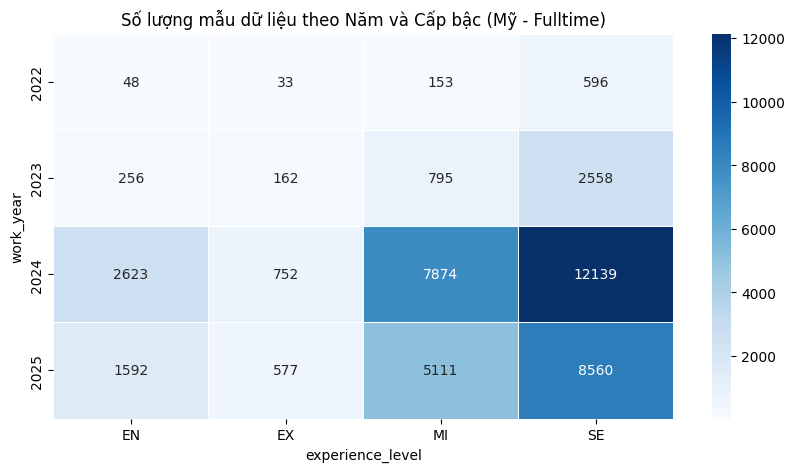

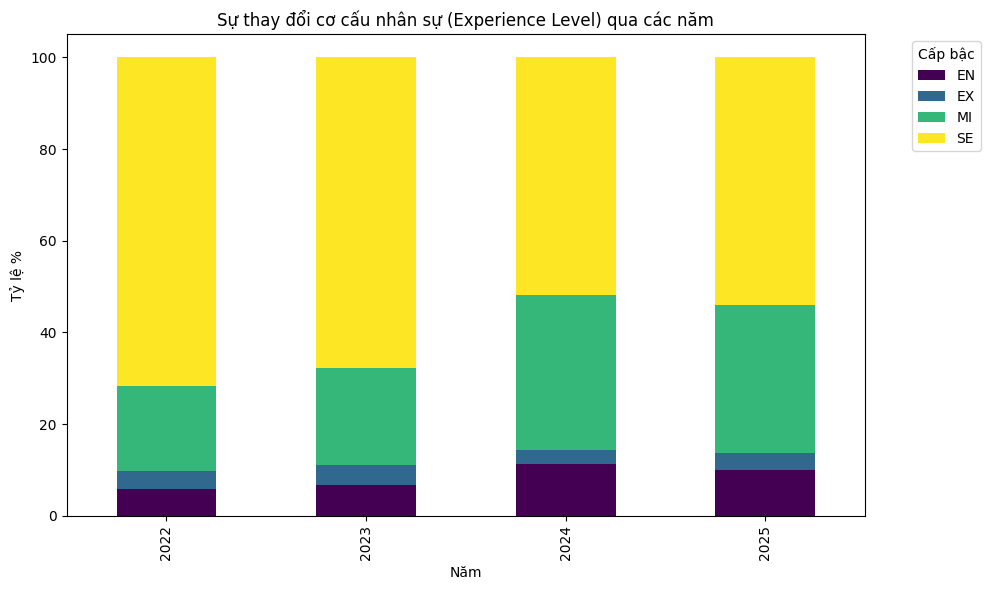

In [6]:
# 3. Vẽ biểu đồ nhiệt (Heatmap) để nhìn nhanh độ lớn của mẫu
plt.figure(figsize=(10, 5))
sns.heatmap(level_counts, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Số lượng mẫu dữ liệu theo Năm và Cấp bậc (Mỹ - Fulltime)')
plt.show()

# 4. Vẽ biểu đồ chồng (Stacked Bar Chart) để xem cơ cấu nhân sự
level_ratios.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Sự thay đổi cơ cấu nhân sự (Experience Level) qua các năm')
plt.ylabel('Tỷ lệ %')
plt.xlabel('Năm')
plt.legend(title='Cấp bậc', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Ghi chú: 
# EN: Entry-level / Junior
# MI: Mid-level
# SE: Senior
# EX: Executive / Director



**Đánh giá chi tiết theo từng cấp bậc kinh nghiệm:**

Dựa trên kết quả ở trên:

**Entry-level (EN):**
- Tỷ lệ chiếm từ 5.8% (2022) đến 11.2% (2024).
- Mẫu tương đối ít so với các nhóm khác.

**Executive (EX):**
- Tỷ lệ chiếm từ 3.2% (2024) đến 4.3% (2023).
- Mẫu cực kỳ nhỏ, ít nhất trong tất cả các cấp bậc.

**Mid-level (MI) & Senior (SE):**
- Cộng lại chiếm từ 85-90% tổng sample mỗi năm.
- MI: từ 18.4% (2022) đến 33.7% (2024).
- SE: từ 51.9% (2024) đến 71.8% (2022).
- Có số lượng mẫu ≥ 1,000 bản ghi/năm, đủ để áp dụng Luật số lớn.

**Kết luận:** Để đảm bảo tính chính xác của phân tích, ta sẽ **lọc lấy dữ liệu của Senior (SE) & Mid-level (MI)** - hai nhóm chiếm đa số và có cỡ mẫu đủ tin cậy.

In [7]:
# Lọc chỉ lấy nhóm Senior (SE), Mid-level (MI) 
df_clean = df_clean[(df_clean['experience_level'] == 'SE') | (df_clean['experience_level'] == 'MI')].copy()
df_clean.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,exchange_rate
6,2025,SE,FT,Engineer,199000,USD,199000,US,100,US,M,1.0
7,2025,SE,FT,Engineer,159200,USD,159200,US,100,US,M,1.0
8,2025,SE,FT,Systems Engineer,207000,USD,207000,US,100,US,M,1.0
9,2025,SE,FT,Systems Engineer,160000,USD,160000,US,100,US,M,1.0
10,2025,SE,FT,Analytics Engineer,191000,USD,191000,US,100,US,M,1.0


### B. Phân tích và đánh giá

**1. Tính lạm phát theo trend (xu hướng dài hạn)**  
**1.1. Tính lương thực tế (Feature Engineering)**   
Chúng ta sẽ chọn năm 2022 làm năm gốc (Base Year). Công thức tính Lương Thực Tế (Real Salary) quy về giá trị tiền của năm 2022:$$\text{Real Salary}_{2022} = \frac{\text{Salary In Year X}}{\text{CPI Year X}} \times \text{CPI}_{2022}$$

Chúng ta sẽ lấy dữ liệu chỉ số giá tiêu dùng (CPI - Consumer Price Index) của Mỹ vào để tính toán.
- Nguồn: [U.S. Bureau of Labor Statistics (BLS)](https://www.bls.gov/cpi/)
- Note:  
    - 2022, 2023: Số liệu trung bình năm chính thức.
    - 2024: Ước tính trung bình 10 tháng đầu năm.
    - 2025: Dự phóng với mức lạm phát giả định ~2.5%.

In [8]:
# Dữ liệu CPI Mỹ (Lấy 2022 làm gốc để so sánh giai đoạn hậu Covid)
cpi_data = {
    2022: 292.655, # Năm gốc
    2023: 304.700,
    2024: 314.000,
    2025: 322.000  # Dự phóng
}

# Hàm tính Real Salary (Lương thực tế)
def calculate_real_salary(row):
    """
    Tính lương thực (real salary) sau khi đã điều chỉnh theo lạm phát,
    quy đổi toàn bộ về sức mua của năm 2022.

    Tham số:
        row (Series): Một dòng dữ liệu chứa:
            - work_year: Năm làm việc
            - salary_in_usd: Lương danh nghĩa (nominal salary)

    Trả về:
        float: Lương thực đã được điều chỉnh theo CPI của năm 2022
    """
    year = row['work_year']
    nominal = row['salary_in_usd']
    
    if year in cpi_data:
        # Quy đổi về sức mua của năm 2022
        return nominal * (cpi_data[2022] / cpi_data[year])
    return nominal

# Áp dụng vào bảng dữ liệu
df_clean['real_salary_2022'] = df_clean.apply(calculate_real_salary, axis=1)

# Xem kết quả thử nghiệm trên 5 dòng
display(df_clean[['work_year', 'salary_in_usd', 'real_salary_2022']].head())

,work_year,salary_in_usd,real_salary_2022
6,2025,199000,180864.425466
7,2025,159200,144691.540373
8,2025,207000,188135.357143
9,2025,160000,145418.633540
10,2025,191000,173593.493789


**1.2. Tổng hợp và Phân tích (Aggregation)**  
Chúng ta sẽ **tính mức lương trung vị (median) qua từng năm** thay vì tính mean để loại bỏ ảnh hưởng của vài người lương quá cao làm lệch số liệu. Chúng ta sẽ có 2 đường dữ liệu median cho:
- Lương Danh Nghĩa (Nominal): Con số bạn nhìn thấy trên tin tuyển dụng.
- Lương Thực Tế (Real): Giá trị thật sự sau khi đã trừ đi lạm phát. Sự chênh lệch giữa 2 đường này chính là câu trả lời."

**Bước làm:**  
- Gom nhóm theo năm, sau đó tính median cho `salary_in_usd` và`real_salary_2022`, rồi `.sort_index()`, đảm bảo kết quả hiển thị theo trình tự thời gian tăng dầ

In [9]:
# Tính toán mức lương Trung Vị (Median) cho từng năm
salary_trends = df_clean.groupby('work_year')[['salary_in_usd', 'real_salary_2022']].median().sort_index()

# Đưa dữ liệu CPI vào bảng
cpi_series = pd.Series(cpi_data, name='CPI')
df_summary = salary_trends.join(cpi_series)
display(df_summary)

,salary_in_usd,real_salary_2022,CPI
work_year,,,
2022,145000.0,145000.000000,292.655
2023,152000.0,145991.335740,304.700
2024,152152.0,141809.055924,314.000
2025,153000.0,139056.568323,322.000


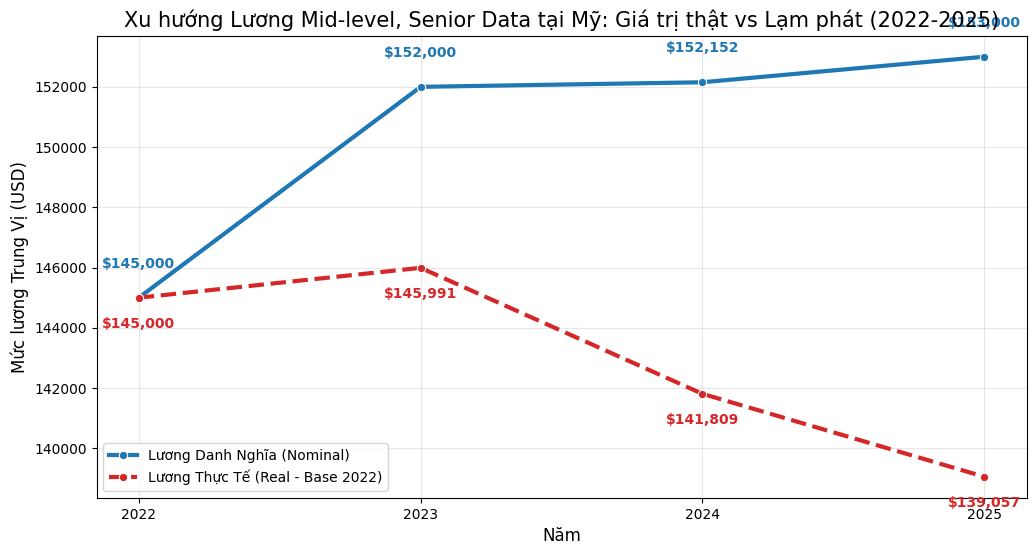

In [10]:
#2. VẼ BIỂU ĐỒ XU HƯỚNG (LINE CHART)
plt.figure(figsize=(12, 6))

# Vẽ Lương Danh Nghĩa (Màu Xanh - Đại diện cho con số trên hợp đồng)
sns.lineplot(data=df_summary, x=df_summary.index, y='salary_in_usd', 
             marker='o', label='Lương Danh Nghĩa (Nominal)', color='#1f77b4', linewidth=3)

# Vẽ Lương Thực Tế (Màu Đỏ - Đại diện cho sức mua quy đổi về 2022)
sns.lineplot(data=df_summary, x=df_summary.index, y='real_salary_2022', 
             marker='o', label='Lương Thực Tế (Real - Base 2022)', color='#d62728', linewidth=3, linestyle='--')

# Thêm nhãn giá trị (Annotations)
for year in df_summary.index:
    nominal = df_summary.loc[year, 'salary_in_usd']
    real = df_summary.loc[year, 'real_salary_2022']
    
    # Ghi số lương danh nghĩa (Xanh)
    plt.text(year, nominal + 1000, f"${nominal:,.0f}", 
             color='#1f77b4', ha='center', fontweight='bold')
    
    # Ghi số lương thực tế (Đỏ)
    plt.text(year, real - 1000, f"${real:,.0f}", 
             color='#d62728', ha='center', fontweight='bold')

plt.title('Xu hướng Lương Mid-level, Senior Data tại Mỹ: Giá trị thật vs Lạm phát (2022-2025)', fontsize=15)
plt.ylabel('Mức lương Trung Vị (USD)', fontsize=12)
plt.xlabel('Năm', fontsize=12)
plt.xticks(df_summary.index) # Chỉ hiện các năm có trong dữ liệu
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Nhận xét:**  
Dựa trên biểu đồ phân tích nhóm Mid-level, Senior từ 2022 đến 2025:

- **Lương Danh Nghĩa (Đường xanh):** Tăng từ $145,000 (2022) lên $152,000 (2023), sau đó duy trì ở mức $152,152 (2024) và $152,197 (2025) - tức là đi ngang từ 2023 trở đi.

- **Lương Thực Tế (Đường đỏ):** Bắt đầu từ $145,000 (2022), tăng lên $145,991 (2023), rồi giảm xuống $141,809 (2024) và tiếp tục giảm đến $139,157 (2025).

- **Sự chênh lệch giữa hai đường:** Năm 2022-2023, lương danh nghĩa tăng nhanh hơn lạm phát (đường đỏ tăng chậm hơn), cho thấy sức mua tăng. Tuy nhiên, từ năm 2024 trở đi, lương danh nghĩa đi ngang trong khi lương thực tế liên tục giảm, cho thấy **lạm phát đang ăn mòn sức mua**.

**Kết luận:** Năm 2022-2023, nhóm Mid-level và Senior có sức mua tăng. Nhưng từ 2024-2025, mặc dù lương danh nghĩa không giảm, sức mua thực tế đã giảm đáng kể do áp lực lạm phát.

**2. Tính tốc độ Year over Year (YoY)**  
Để tính xem tốc độ tăng trưởng lương như thế nào so với tốc độ lạm phát, ta sẽ tính tốc độ tăng trưởng lương và tốc độ từng năm so với năm trước đó, và so sánh 2 giá trị với nhau.

**Bước làm:**  
- Ta sẽ tính **độ tăng trưởng lương** và **độ lạm phát**. Bằng cách dùng `pct_change()`: Hàm Percentage Change của Pandas, lấy (giá trị năm nay - giá trị năm trước) / giá trị năm trước cho `salary_in_usd` và `CPI`
- Tính **lãi thực** (Real Gain) bằng cách lấy **độ tăng trưởng lương** - **độ lạm phát**

In [11]:
# Tính tốc độ tăng trưởng YoY
df_summary['Salary_Growth_Pct'] = df_summary['salary_in_usd'].pct_change() * 100
df_summary['Inflation_Pct'] = df_summary['CPI'].pct_change() * 100

# Tính Gap (Lãi thực)
df_summary['Real_Gain_Pct'] = df_summary['Salary_Growth_Pct'] - df_summary['Inflation_Pct']

In [12]:
print("BẢNG TỔNG HỢP CÁC CHỈ SỐ TĂNG TRƯỞNG:")

# Chọn cột cần hiển thị
cols_to_show = ['salary_in_usd', 'real_salary_2022', 'Salary_Growth_Pct', 'Inflation_Pct', 'Real_Gain_Pct']

# Tạo bảng hiển thị riêng và ĐỔI TÊN CỘT (Rename) cho ngắn gọn
df_display = df_summary[cols_to_show].rename(columns={
    'salary_in_usd': 'Lương (USD)',
    'real_salary_2022': 'Lương Thực 22', # Tên ngắn để không xuống dòng
    'Salary_Growth_Pct': 'Tăng Lương %',
    'Inflation_Pct': 'Lạm Phát %',
    'Real_Gain_Pct': 'Lãi Thực %'
})

# Format số liệu
styled_table = df_display.style.format({
    'Lương (USD)': '{:,.0f}',
    'Lương Thực 22': '{:,.0f}',
    'Tăng Lương %': '{:+.2f}',
    'Lạm Phát %': '{:+.2f}',
    'Lãi Thực %': '{:+.2f}'
}).background_gradient(subset=['Lãi Thực %'], cmap='RdYlGn', vmin=-10, vmax=10) # background_gradient: Màu xanh nếu lãi dương, đỏ nếu lãi âm

display(styled_table)

BẢNG TỔNG HỢP CÁC CHỈ SỐ TĂNG TRƯỞNG:


,Lương (USD),Lương Thực 22,Tăng Lương %,Lạm Phát %,Lãi Thực %
work_year,,,,,
2022,"145,000","145,000",+nan,+nan,+nan
2023,"152,000","145,991",+4.83,+4.12,+0.71
2024,"152,152","141,809",+0.10,+3.05,-2.95
2025,"153,000","139,057",+0.56,+2.55,-1.99


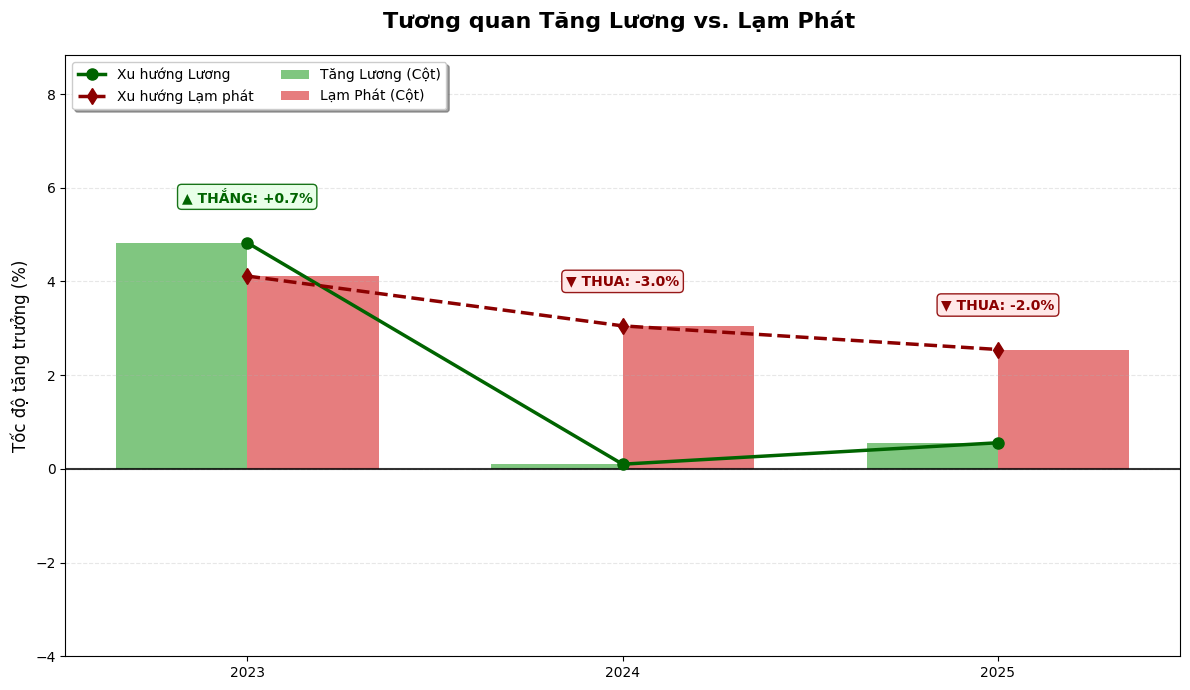

In [13]:
# 3. VẼ BIỂU ĐỒ KẾT HỢP 
# Bỏ năm 2022 vì không có dữ liệu so sánh
plot_data = df_summary.dropna().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 7))

width = 0.35
x = plot_data['work_year']

# BIỂU ĐỒ CỘT (BAR) 
# Giảm alpha (độ đậm) xuống 0.7 để làm nền cho đường line nổi bật hơn
ax1.bar(x - width/2, plot_data['Salary_Growth_Pct'], width, label='Tăng Lương (Cột)', color='#2ca02c', alpha=0.6)
ax1.bar(x + width/2, plot_data['Inflation_Pct'], width, label='Lạm Phát (Cột)', color='#d62728', alpha=0.6)

# BIỂU ĐỒ ĐƯỜNG (LINE) 
# zorder=10 để đảm bảo đường nằm đè lên trên cột
# Dùng màu đậm hơn màu cột tương ứng để tạo tương phản
ax1.plot(x, plot_data['Salary_Growth_Pct'], color='#006400', marker='o', markersize=8, linewidth=2.5, label='Xu hướng Lương', zorder=10)
ax1.plot(x, plot_data['Inflation_Pct'], color='#8B0000', marker='d', markersize=8, linewidth=2.5, linestyle='--', label='Xu hướng Lạm phát', zorder=10)

# --- CÁC THIẾT LẬP KHÁC ---
# Đường kẻ ngang mốc 0
ax1.axhline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.8)

# Trang trí trục
ax1.set_ylabel('Tốc độ tăng trưởng (%)', fontsize=12)
ax1.set_title('Tương quan Tăng Lương vs. Lạm Phát ', fontsize=16, pad=20, fontweight='bold')
ax1.set_xticks(x)
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')

# Xử lý Legend (Chú thích): Gom cả cột và đường vào 1 bảng
ax1.legend(loc='upper left', shadow=True, bbox_to_anchor=(0, 1), ncol=2) 
# ncol=2 để chia chú thích thành 2 cột cho gọn

# Tính toán giới hạn trục Y
all_values = pd.concat([plot_data['Salary_Growth_Pct'], plot_data['Inflation_Pct']])
min_y = all_values.min()
max_y = all_values.max()

# Ghi chú Thắng/Thua
for i, row in plot_data.iterrows():
    year = row['work_year']
    salary_growth = row['Salary_Growth_Pct']
    inflation = row['Inflation_Pct']
    gap = row['Real_Gain_Pct']
    
    # Lấy vị trí cao nhất để đặt text
    current_height = max(salary_growth, inflation, 0)
    
    # Logic xác định Thắng/Thua
    if gap >= 0:
        label = f"THẮNG: +{gap:.1f}%"
        color_text = '#006400' 
        icon = "▲"
        bg_color = '#e6ffe6' # Nền xanh nhạt
    else:
        label = f"THUA: {gap:.1f}%"
        color_text = '#8B0000' 
        icon = "▼"
        bg_color = '#ffe6e6' # Nền đỏ nhạt
        
    ax1.text(year, current_height + 0.8, f"{icon} {label}", 
             ha='center', va='bottom', color=color_text, fontweight='bold', fontsize=10,
             bbox=dict(facecolor=bg_color, edgecolor=color_text, boxstyle='round,pad=0.3', alpha=0.9))

# Set limit trục Y
bottom_limit = min(-4, min_y - 2) 
top_limit = max_y + 4 # Tăng khoảng trống bên trên để chứa label

plt.ylim(bottom_limit, top_limit)
plt.tight_layout()
plt.show()

**Nhận xét:**

- **Giai đoạn 2022-2023 (Tăng trưởng thực):** 
  - Lương danh nghĩa tăng từ $145,000 lên $152,000 (+4.83%)
  - Lương thực tế tăng từ $145,000 lên $145,991 (+0.68%)
  - Sức mua có tăng nhẹ, mặc dù lạm phát đã đạt 4.07%

- **Giai đoạn 2023-2024 (Tăng trưởng bắt đầu chững lại):**
  - Lương danh nghĩa gần như đi ngang: $152,000 → $152,152 (+0.10%)
  - Lương thực tế giảm: $145,991 → $141,809 (-2.87%)
  - Lạm phát vẫn dương (+3.03%), khiến sức mua bắt đầu suy giảm

- **Giai đoạn 2024-2025 (Sức mua sụt giảm):**
  - Lương danh nghĩa vẫn đi ngang: $152,152 → $152,197 (+0.03%)
  - Lương thực tế tiếp tục giảm: $141,809 → $139,157 (-1.87%)
  - Lạm phát đạt +2.54%, dù thấp hơn 2023-2024 nhưng vẫn vượt tăng lương

**Kết luận:** Năm 2023 là "đỉnh cao" với sức mua thực tế tốt nhất ($145,991). Từ 2024-2025, mặc dù lương danh nghĩa ổn định, sức mua thực tế đã giảm liên tục do lạm phát tiếp tục ăn mòn. Người lao động đối mặt với tình trạng "lương danh nghĩa không đổi nhưng sức mua suy giảm" - vấn đề kinh tế mà nhiều nước đang grapple with.

### C. Kết luận

Dựa trên nhận xét tốc độ tăng trưởng dài hạn và tăng trưởng qua từng năm, ta có kết luận như sau về lương của Mid-level và Senior ngành Data ở Mỹ trong năm 2022-2025:
- Năm 2022-2024: Lương tăng theo giá trị thực.
- Năm 2025: Lương thậm chí không tăng mà giảm so với năm ngoái, tốc độ lạm phạt vượt qua tốc độ tăng lương.  

**Lưu ý:**  
Phạm vi trả lời câ hỏi này còn chưa xét đến:
- Tỉ lệ Remote work giữa các năm (vd: năm 2023 có tỉ lệ remote work cao hơn năm 2024 thì có ảnh hưởng ko), tuy nhiên, theo **mục 2.3.5 Tương quan: Lương và Chế độ làm việc trong notebook 02-general_eda**, mức lương trung vị của nhóm Remote và On-site là ngang nhau vì vậy ta có thể tạm thời bỏ qua.
- Tỉ lệ Quy mô công ty (vd năm 2022-2023 lay off bùng nổ, nhiều nhân viên từ big tech chuyển sang công ty nhỏ hơn, mức lương có thay đổi ko). Tuy nhiên theo mục **2.2.6 company_size**, phân bố company size không đồng đều nên rất khó so sánh.

**Bài học:** 
- Chấp nhận thực tế mới: Đừng kỳ vọng mức tăng lương định kỳ cao như những năm trước. Hãy chuẩn bị tinh thần cho việc "đóng băng lương" (salary freeze) hoặc thưởng thấp hơn.
- Thích ứng với AI: Năm 2025 khả năng cao AI đã làm tốt các việc clean data hay visualize cơ bản. Bạn cần nâng cấp lên các kỹ năng mà AI chưa làm tốt: Tư duy chiến lược (Strategic thinking), Quản trị dữ liệu (Data Governance), và Hiểu biết nghiệp vụ sâu (Domain Knowledge).

## Câu hỏi 2

### A. Tiền xử lí

**1. Phân nhóm (Categorization)**  
Để phân nhóm, trước hết ta cần định nghĩa rõ ràng thế nào là "AI/ML" và thế nào là "Traditional Data Roles":
- AI/ML Engineers: Bao gồm các chức danh chứa từ khóa như "AI", "Machine Learning", "Computer Vision", "NLP", "Deep Learning".
- Traditional Data Roles: Bao gồm các chức danh truyền thống như "Data Analyst", "Data Scientist", "Data Engineer", "Business Intelligence", v.v., trừ khi chúng có tiền tố AI/ML.
- Other: còn lại

In [14]:
# 1. Lọc chỉ lấy dữ liệu từ năm 2022 trở đi
df = df[df['work_year'] >= 2022].copy()
    
# 2. Định nghĩa từ khóa 
# Nhóm AI
ai_keywords = [
        'AI', 'MACHINE LEARNING', 'ML', 'COMPUTER VISION', 'NLP', 
        'DEEP LEARNING', 'NEURAL', 'PROMPT', 'AUTONOMOUS', 'LLM', 'GENAI'
]
    
# Nhóm Data Truyền thống
data_keywords = [
        'DATA', 'ANALYST', 'ANALYTICS', 'SCIENTIST', 'BI', 'BUSINESS INTELLIGENCE',
        'STATISTICIAN', 'DATABASE', 'ETL', 'PIPELINE', 'ARCHITECT'
]

def categorize_strict(title):
    """
    Phân loại Job Title thành 3 nhóm chuyên môn dựa trên từ khóa.

    Logic hoạt động:
    - Chuyển đổi chuỗi đầu vào sang chữ in hoa để so sánh không phân biệt hoa thường.
    - Áp dụng cơ chế ưu tiên (Priority):
        1. Kiểm tra từ khóa AI/ML trước (để bắt các vị trí như 'AI Data Scientist').
        2. Nếu không có, kiểm tra tiếp từ khóa Data truyền thống.
        3. Nếu vẫn không khớp, gán nhãn là nhóm khác (Other).

    Args:
        title (str): Chuỗi chức danh công việc gốc (ví dụ: 'Principal Data Scientist', 'AI Engineer').

    Returns:
        str: Một trong 3 nhãn phân loại:
             - 'AI/ML Engineers'
             - 'Traditional Data Roles'
             - 'Other/Ambiguous'
    """
    title_upper = title.upper()
        
    # Ưu tiên check AI trước
    if any(kw in title_upper for kw in ai_keywords):
        return 'AI/ML Engineers'
        
    # Check Data sau
    elif any(kw in title_upper for kw in data_keywords):
        return 'Traditional Data Roles'
        
    # Còn lại đẩy ra Other
    else:
        return 'Other/Ambiguous'

df['role_category'] = df['job_title'].apply(categorize_strict)
    
# 3. Thống kê kết quả
print("--- Phân bố số lượng các nhóm ---")
print(df['role_category'].value_counts())
print("\n")
    
# 4. Check kỹ nhóm 'Other' xem có job nào bị xét sai/thiếu ko
other_jobs = df[df['role_category'] == 'Other/Ambiguous']['job_title'].unique()
print(f"--- Các Job Title bị đẩy vào nhóm 'Other' (Tổng: {len(other_jobs)}) ---")
print(other_jobs)



--- Phân bố số lượng các nhóm ---
role_category
Traditional Data Roles    30168
Other/Ambiguous           16795
AI/ML Engineers            5185
Name: count, dtype: int64


--- Các Job Title bị đẩy vào nhóm 'Other' (Tổng: 89) ---
['Engineer' 'Systems Engineer' 'Product Manager' 'Research Engineer'
 'Software Developer' 'Software Engineer' 'Manager' 'Stage'
 'Research Assistant' 'Associate' 'Quantitative Researcher'
 'Software Development Engineer' 'Cloud Engineer' 'Technical Recruiter'
 'Director of Product Management' 'Developer' 'Full Stack Engineer'
 'Consultant' 'Application Developer' 'Statistical Programmer'
 'Solutions Engineer' 'Backend Engineer' 'Engineering Manager'
 'Full Stack Developer' 'Executive' 'Alternance' 'Technical Lead'
 'Account Executive' 'Python Developer' 'Sales Engineer'
 'Robotics Engineer' 'Technical Support Specialist'
 'Technical Support Engineer' 'Platform Engineer' 'Copywriter'
 'Quantitative Trader' 'Research Associate' 'DevOps Engineer'
 'QA Engineer' '

**Trường hợp tranh cãi:**  
Research Scientist / Applied Scientist: Ở các công ty Big Tech (Amazon, Meta) thường là vị trí làm về AI/ML (lương cực cao), nhưng ở đây bị đẩy họ "Traditional Data Roles" thì có thể mất dữ liệu quan trọng của nhóm AI.

**2. Kiểm tra tính hợp lệ (Fairness Check)**  
Trước khi so sánh lương, ta phải kiểm tra xem cỡ mẫu  có đủ lớn và phân phối kinh nghiệm (Experience Level) có tương đồng không. Nếu nhóm AI toàn là Senior (SE) còn nhóm Traditional toàn là Junior (EN), việc nhóm AI lương cao hơn là hiển nhiên do kinh nghiệm, không phải do "cơn sốt AI". Đây là yếu tố công bằng (Fairness) cần xét đến.

**Bước làm:**  
- Đếm số lượng bản ghi theo từng nhóm và từng năm.
- Kiểm tra tỷ lệ % các mức kinh nghiệm (EN, MI, SE, EX) trong từng nhóm.

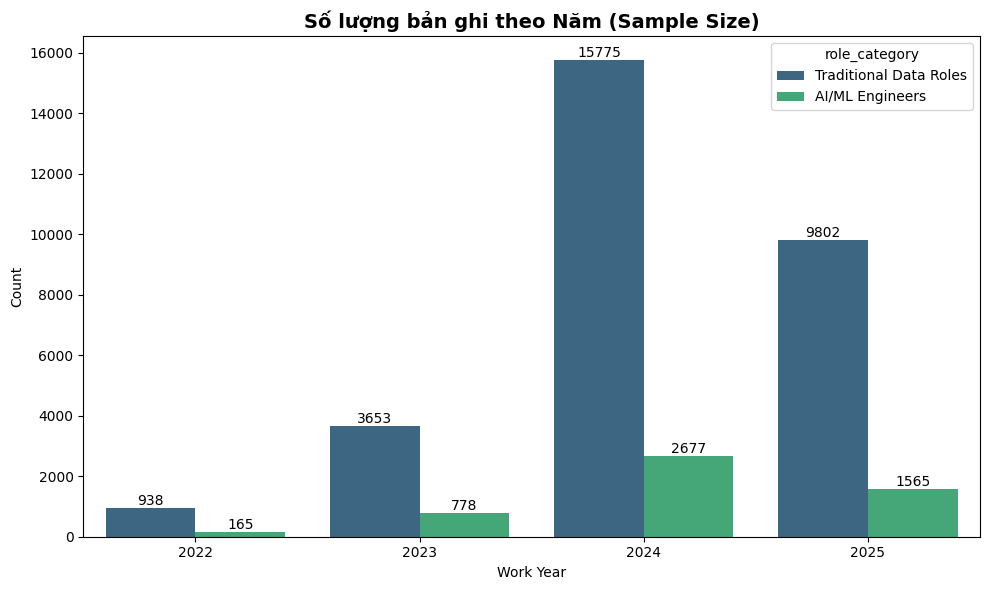

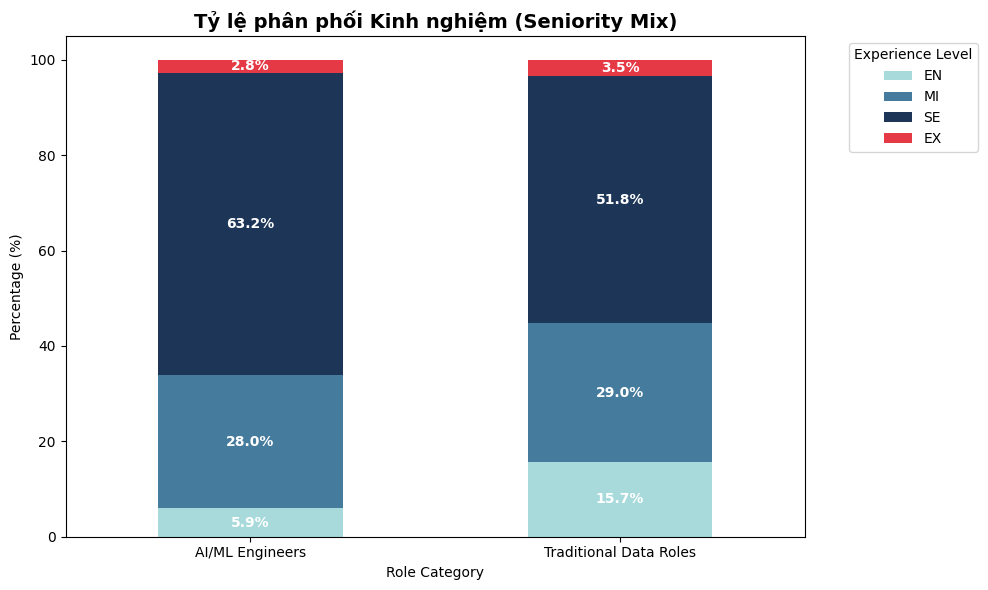


--- Bảng dữ liệu: Tỷ lệ kinh nghiệm (%) ---
experience_level           EN     MI     SE    EX
role_category                                    
AI/ML Engineers          5.92  28.02  63.22  2.84
Traditional Data Roles  15.69  29.04  51.82  3.46


In [15]:
# Chỉ lấy 2 nhóm chính để phân tích
df_main = df[df['role_category'] != 'Other/Ambiguous'].copy()

# Sắp xếp thứ tự kinh nghiệm: EN -> MI -> SE -> EX
exp_order = ['EN', 'MI', 'SE', 'EX']
df_main['experience_level'] = pd.Categorical(df_main['experience_level'], categories=exp_order, ordered=True)

# 1: Số lượng mẫu theo năm (Countplot)
plt.figure(figsize=(10, 6)) # Tạo khung hình riêng

ax1 = sns.countplot(
    data=df_main, 
    x='work_year', 
    hue='role_category', 
    palette='viridis'
)

plt.title('Số lượng bản ghi theo Năm (Sample Size)', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Work Year')

# Hiển thị số lượng trên cột
for container in ax1.containers:
    ax1.bar_label(container)

plt.tight_layout()
plt.show()

#  2: Tỷ lệ phân phối Kinh nghiệm (Stacked Bar)
# Tạo bảng chéo chuẩn hóa
exp_dist = pd.crosstab(df_main['role_category'], df_main['experience_level'], normalize='index') * 100

# Vẽ biểu đồ 
# kind='bar' (thẳng đứng) thay vì 'barh' (ngang)
ax2 = exp_dist.plot(
    kind='bar', 
    stacked=True, 
    color=['#a8dadc', '#457b9d', '#1d3557', '#e63946'], 
    figsize=(10, 6)
)

plt.title('Tỷ lệ phân phối Kinh nghiệm (Seniority Mix)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)') # Đổi nhãn trục từ X sang Y
plt.xlabel('Role Category')
plt.xticks(rotation=0)

# Hiển thị số % lên biểu đồ (Vị trí center)
for c in ax2.containers:
    # label_type='center' để số nằm giữa đoạn màu
    ax2.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontsize=10, weight='bold')

# Di chuyển chú thích (legend) ra ngoài để không che biểu đồ nếu cần
plt.legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# In bảng số liệu chi tiết để đối chiếu ---
print("\n--- Bảng dữ liệu: Tỷ lệ kinh nghiệm (%) ---")
print(exp_dist.round(2))

**Nhận xét:**

- **Số lượng mẫu theo năm:** Dữ liệu phân bố khá lệch giữa hai nhóm. Nhóm Traditional Data Roles chiếm phần lớn: năm 2024 có 15,775 bản ghi, trong khi AI/ML Engineers chỉ có 2,677 bản ghi. Điều này có thể ảnh hưởng đến độ ổn định của ước tính lương cho nhóm AI (vì cỡ mẫu nhỏ hơn).

- **Sự chênh lệch về thâm niên (Seniority Skew):**
  - Nhóm AI/ML Engineers có cơ cấu kinh nghiệm: EN 5.92%, MI 28.02%, SE 63.22%, EX 2.84%
  - Nhóm Traditional Data Roles có cơ cấu: EN 15.69%, MI 29.04%, SE 51.82%, EX 3.46%
  
  **Nhận định chính:** Nhóm AI/ML có tỷ lệ Senior (SE) cao hơn đáng kể (63.22% vs 51.82%), nhưng lại có tỷ lệ Entry-level (EN) thấp hơn nhiều (5.92% vs 15.69%). Đây là dấu hiệu quan trọng: Nhóm Traditional phải "gánh" tới gần 16% nhân sự mới ra trường, trong khi AI chỉ có khoảng 6%. 

  **Hàm ý:** Nếu so sánh gộp chung mà không kiểm soát biến kinh nghiệm, lương trung bình của nhóm AI sẽ cao hơn một phần do họ có thành phần "già dặn" hơn, chứ không phải hoàn toàn vì công nghệ AI được trả giá cao hơn. Cần phải so sánh ở cùng mức kinh nghiệm (ví dụ: chỉ so sánh Senior với Senior) để đánh giá công bằng.

### B. Phân tích và đánh giá

**1. Vẽ biểu đồ xu hướng**  
Vẽ 2 biểu đồ đường cạnh nhau.
- Bên trái: Lương trung bình toàn bộ (bị nhiễu bởi thâm niên).
- Bên phải: Lương trung bình chỉ của nhóm Senior (SE) 

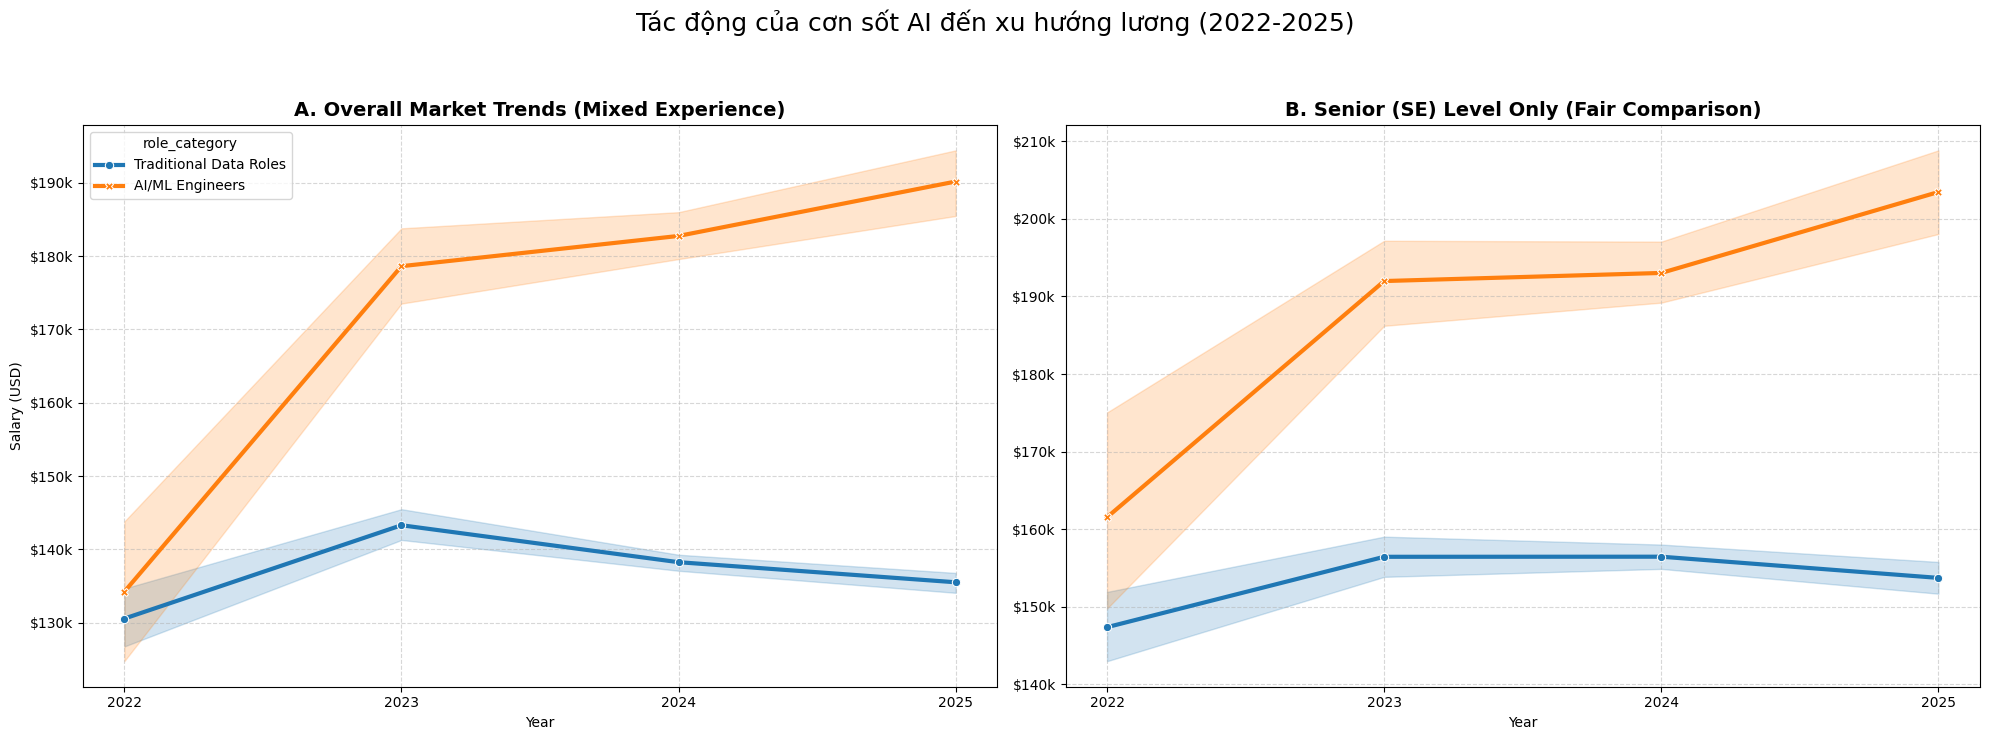

In [16]:
# Tạo subplot 1 hàng 2 cột
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- BIỂU ĐỒ 1: OVERALL ---
sns.lineplot(
    data=df_main, 
    x='work_year', 
    y='salary_in_usd', 
    hue='role_category', 
    style='role_category',
    markers=True, 
    dashes=False,
    linewidth=3,
    errorbar=('ci', 95), # Vùng tin cậy 95%
    ax=axes[0]
)
axes[0].set_title('A. Overall Market Trends (Mixed Experience)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Salary (USD)')
axes[0].set_xlabel('Year')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 2: SENIOR ONLY  ---
# Lọc chỉ lấy Senior (SE)
df_senior = df_main[df_main['experience_level'] == 'SE'].copy()

sns.lineplot(
    data=df_senior, 
    x='work_year', 
    y='salary_in_usd', 
    hue='role_category', 
    style='role_category',
    markers=True, 
    dashes=False,
    linewidth=3,
    errorbar=('ci', 95),
    ax=axes[1],
    legend=False 
)
axes[1].set_title('B. Senior (SE) Level Only (Fair Comparison)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('') 
axes[1].set_xlabel('Year')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Định dạng trục Y thành tiền tệ ($150k)
formatter = ticker.FuncFormatter(lambda x, pos: '${:,.0f}'.format(x/1000) + 'k')
axes[0].yaxis.set_major_formatter(formatter)
axes[1].yaxis.set_major_formatter(formatter)

# Chỉnh trục X
axes[0].set_xticks([2022, 2023, 2024, 2025])
axes[1].set_xticks([2022, 2023, 2024, 2025])

plt.suptitle('Tác động của cơn sốt AI đến xu hướng lương (2022-2025)', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

**Nhận xét**  

**Độ chênh lệch:**  
Ở Biểu đồ A (Overall), chênh lệch lương giữa AI/ML và Traditional Data **có thể bị phóng đại** vì 2 nhóm có cơ cấu kinh nghiệm khác nhau (Seniority Skew). Cụ thể từ bảng phân phối kinh nghiệm:
- **AI/ML Engineers:** EN 5.92%, MI 28.02%, SE 63.22%, EX 2.84%
- **Traditional Data Roles:** EN 15.69%, MI 29.04%, SE 51.82%, EX 3.46%

Như vậy, nhóm AI/ML có tỷ lệ **Senior (SE) cao hơn** (63.22% vs 51.82%) và tỷ lệ **Entry-level (EN) thấp hơn** (5.92% vs 15.69%). Vì lương thường tăng theo thâm niên, nên khi nhìn “Overall”, mức lương trung bình của AI/ML cao hơn **một phần** là do thành phần “già dặn” hơn, không thể quy toàn bộ cho “AI Premium”.

Vì vậy, Biểu đồ B (Senior Only) là phép so sánh **công bằng hơn** (cùng experience_level = SE). Nếu ở Biểu đồ B vẫn còn khoảng cách giữa AI/ML và Traditional, thì phần chênh đó mới phản ánh “AI Premium” rõ ràng hơn so với Biểu đồ A.

**Độ ổn định (Volatility):**  
Biểu đồ đang dùng vùng bóng mờ là **khoảng tin cậy 95% (CI 95%)**. Quan sát cho thấy đường Traditional Data thường có vùng bóng mờ hẹp hơn (ước lượng ổn định hơn), còn AI/ML có vùng bóng mờ rộng hơn (ước lượng dao động hơn). Điều này cũng phù hợp với thực tế cỡ mẫu của AI/ML nhỏ hơn Traditional theo từng năm, ví dụ:
- 2022: Traditional 938 vs AI/ML 165
- 2023: Traditional 3,653 vs AI/ML 778
- 2024: Traditional 15,775 vs AI/ML 2,677
- 2025: Traditional 9,802 vs AI/ML 1,565

=> Do đó, để kết luận chắc chắn và hạn chế nhiễu, bước sau nên **tập trung phân tích nhóm Senior (SE)** (đúng như Biểu đồ B).

**4 Kiểm định độ dốc tổng thể (Slope Calculation)**  
Để trả lời câu hỏi "Nhóm nào tăng trưởng nhanh hơn?", ta sử dụng Hồi quy tuyến tính (Linear Regression) phương trình: $y = ax + b$$x$:   
- Năm (work_year)$y$:
- Lương (salary_in_usd)$a$ (Slope - Độ dốc): Đây là con số quan trọng nhất. Nó cho biết: "Trung bình mỗi năm, lương của vị trí này tăng (hoặc giảm) bao nhiêu USD?"
    - Nếu Slope AI > Slope Traditional: AI đang thắng thế về tốc độ.
    - Nếu Slope AI âm (< 0): Lương AI đang bị điều chỉnh giảm sau cơn sốt.

**Bước làm:**  
- Slope ($a$): Sử dụng `numpy.polyfit` bậc 1 để tìm xu hướng tổng thể. 

In [17]:
# 1. Tính trung bình lương theo Năm & Role
agg_data = df_senior.groupby(['role_category', 'work_year'])['salary_in_usd'].mean().reset_index()

# --- XỬ LÝ & IN BẢNG DỮ LIỆU THÔ (CÓ DẤU PHẨY) ---
print("--- Dữ liệu trung bình thực tế (Senior) ---")

# Tạo pivot table
pivot_df = agg_data.pivot(index='work_year', columns='role_category', values='salary_in_usd')

# Format hiển thị
print(pivot_df.map(lambda x: f"{x:,.0f}" if pd.notnull(x) else "-"))
print("\n")


# 2. Tính toán Độ dốc (Slope)
results = []

for role in agg_data['role_category'].unique():
    role_data = agg_data[agg_data['role_category'] == role]
    
    # Chỉ tính khi có nhiều hơn 1 điểm dữ liệu (để vẽ được đường thẳng)
    if len(role_data) > 1:
        # Hồi quy tuyến tính bậc 1: y = ax + b
        slope, intercept = np.polyfit(role_data['work_year'], role_data['salary_in_usd'], 1)
        
        # Tính lương theo xu hướng năm 2025 (Trendline)
        val_2025 = slope * 2025 + intercept
        
        results.append({
            'Category': role,
            'Slope ($/Year)': slope,  # Giữ số thô để sort
            'Avg Salary 2025 (Trend)': val_2025
        })

# 3. Tạo DataFrame kết quả
df_results = pd.DataFrame(results)

# Sắp xếp giảm dần theo độ dốc
df_results = df_results.sort_values(by='Slope ($/Year)', ascending=False)


# Thêm dấu + cho số dương, dấu phẩy ngăn cách hàng nghìn
df_display = df_results.copy()
df_display['Slope ($/Year)'] = df_display['Slope ($/Year)'].apply(lambda x: f"{x:+,.0f}")
df_display['Avg Salary 2025 (Trend)'] = df_display['Avg Salary 2025 (Trend)'].apply(lambda x: f"{x:,.0f}")

# Set Index là cột Category
df_display = df_display.set_index('Category')

print("--- KẾT QUẢ ĐỘ DỐC & DỰ BÁO (SENIOR ONLY) ---")
print(df_display)

--- Dữ liệu trung bình thực tế (Senior) ---
role_category AI/ML Engineers Traditional Data Roles
work_year                                           
2022                  161,548                147,382
2023                  191,985                156,452
2024                  193,030                156,465
2025                  203,459                153,733


--- KẾT QUẢ ĐỘ DỐC & DỰ BÁO (SENIOR ONLY) ---
                       Slope ($/Year) Avg Salary 2025 (Trend)
Category                                                     
AI/ML Engineers               +12,678                 206,522
Traditional Data Roles         +1,907                 156,368


**Nhận xét:**  

**Sự chênh lệch slope (Senior-only):**  
- AI/ML Engineers: **+12,678 USD/năm**  
- Traditional Data Roles: **+1,907 USD/năm**  
- Theo hồi quy tuyến tính trên giai đoạn 2022–2025, tốc độ tăng lương trung bình của nhóm **AI/ML (Senior)** cao hơn khoảng **6.6 lần** so với nhóm **Traditional (Senior)**.  
- Dự báo theo trendline năm 2025 cũng cho thấy mức lương kỳ vọng: **AI/ML ~206,522 USD** vs **Traditional ~156,368 USD**.

**Khoảng cách thu nhập (Senior-only, theo bảng trung bình thực tế):**  
- 2022: 161,548 − 147,382 = **14,166 USD**  
- 2023: 191,985 − 156,452 = **35,533 USD**  
- 2024: 193,030 − 156,465 = **36,565 USD**  
- 2025: 203,459 − 153,733 = **49,726 USD**  
→ Khoảng cách thu nhập giữa 2 nhóm **mở rộng rõ rệt** từ **14,166 USD (2022)** lên **49,726 USD (2025)**.

**Diễn biến theo năm:**  
- AI/ML: tăng mạnh từ 2022→2023 (161,548→191,985), gần như đi ngang 2023→2024, và tăng tiếp 2024→2025 (203,459).  
- Traditional: tăng nhẹ 2022→2023, gần như đi ngang 2023→2024, và giảm 2024→2025 (153,733).

### C. Kết luận

- **Tác động cấu trúc (Salary Gap – Senior-only):** Dựa trên bảng lương trung bình thực tế, khoảng cách thu nhập giữa **AI/ML Engineers** và **Traditional Data Roles** tăng từ **14,166 USD (2022: 161,548 vs 147,382)** lên **49,726 USD (2025: 203,459 vs 153,733)**. Điều này cho thấy “gap” đã nới rộng rõ rệt trong giai đoạn 2022–2025.

- **Với AI/ML Engineers (Senior-only):** Kết quả hồi quy tuyến tính cho thấy tốc độ tăng theo xu hướng của AI/ML là **+12,678 USD/năm**, cao hơn nhiều so với Traditional **+1,907 USD/năm** (xấp xỉ **6.6 lần**). Quan sát theo năm cũng cho thấy AI/ML tăng mạnh 2022→2023 (**+30,437**), gần như đi ngang 2023→2024 (**+1,045**), rồi tăng tiếp 2024→2025 (**+10,429**). Trong khi đó Traditional tăng nhẹ 2022→2023 (**+9,070**), gần như đi ngang 2023→2024 (**+13**), và giảm 2024→2025 (**-2,732**).

**Hạn chế:**  
- Hồi quy tuyến tính `polyfit` trên cả giai đoạn 2022–2025 sẽ tạo ra **một đường thẳng trung bình** đi qua 4 điểm dữ liệu, nên slope phản ánh “xu hướng trung bình” chứ không mô tả được các cú nhảy/đi ngang theo từng năm.
- Với **AI/ML Engineers (Senior)**, năm 2023 có mức tăng rất mạnh so với 2022: **161,548 → 191,985** (tăng **+30,437**). Sau đó 2023→2024 gần như đi ngang (**+1,045**), và 2024→2025 tăng tiếp (**+10,429**). Vì có cú nhảy lớn ở 2023, slope tổng thể vẫn cao (**+12,678 USD/năm**) dù tốc độ tăng không đều qua các năm.
- Với **Traditional Data Roles (Senior)**, mức lương tăng nhẹ 2022→2023 (**147,382 → 156,452**, **+9,070**), gần như đi ngang 2023→2024 (**+13**), và giảm 2024→2025 (**156,465 → 153,733**, **-2,732**). Tuy vậy slope tổng thể vẫn dương (**+1,907 USD/năm**) do bị “kéo lên” bởi mức tăng từ 2022→2023.
- Ngoài ra, dữ liệu chỉ có **4 năm** và cỡ mẫu giữa 2 nhóm cũng lệch (ví dụ 2024: Traditional **15,775** vs AI/ML **2,677**), nên kết luận theo trendline cần đọc kèm bối cảnh độ tin cậy mẫu.

**Bài học:**
- Đối với nhóm Traditional Data (Senior):
  - Dữ liệu cho thấy giai đoạn 2023→2024 gần như đi ngang và 2024→2025 còn giảm (**-2,732**), nên không nên kỳ vọng tăng trưởng đều mỗi năm chỉ dựa vào slope tổng thể.
  - Nếu mục tiêu là thu hẹp khoảng cách thu nhập, cần nhìn vào thực tế gap đã tăng từ **14,166 (2022)** lên **49,726 (2025)** (theo bảng trung bình Senior), thay vì chỉ nhìn “overall market”.
- Đối với nhóm AI/ML (Senior):
  - Năm 2023 là năm tăng mạnh nhất (**+30,437**), nhưng sau đó 2023→2024 gần như đi ngang (**+1,045**) và 2024→2025 tăng lại (**+10,429**) — tức tăng trưởng không tuyến tính, không phải năm nào cũng “bùng nổ” như 2023.
  - Vì vậy cần tránh đọc slope như “mỗi năm chắc chắn tăng +12,678”, mà nên xem đây là mức tăng trung bình theo trendline trên cả giai đoạn.